In [1]:
pip install numpy

You should consider upgrading via the 'c:\Users\KIIT\AppData\Local\Programs\Python\Python38\python.exe -m pip install --upgrade pip' command.


In [2]:
import pandas as pd
import numpy as np

In [3]:
# Parameters
num_funds = 100
start_date = pd.to_datetime('2024-01-01')

# Generate Data
data = []

for fund_id in range(1, num_funds + 1):
    # Generate aggregated data for each fund
    avg_nav = np.round(np.random.uniform(10, 100), 2)
    avg_return = np.round(np.random.normal(0.05, 0.02), 2)
    risk_level = np.random.choice(['Low', 'Medium', 'High'])
    sector_exposure = {
        'Technology': np.round(np.random.uniform(10, 50), 2),
        'Healthcare': np.round(np.random.uniform(10, 50), 2),
        'Finance': np.round(np.random.uniform(10, 50), 2),
        'Energy': np.round(np.random.uniform(5, 20), 2)
    }
    avg_interest_rate = np.round(np.random.uniform(0.5, 5), 2)
    avg_inflation_rate = np.round(np.random.uniform(1, 4), 2)

    data.append({
        'Fund_ID': fund_id,
        'Date': start_date,  # Use a fixed date or remove if not needed
        'Average_NAV': avg_nav,
        'Average_Return_%': avg_return,
        'Risk_Level': risk_level,
        'Tech_Exposure_%': sector_exposure['Technology'],
        'Healthcare_Exposure_%': sector_exposure['Healthcare'],
        'Finance_Exposure_%': sector_exposure['Finance'],
        'Energy_Exposure_%': sector_exposure['Energy'],
        'Average_Interest_Rate_%': avg_interest_rate,
        'Average_Inflation_Rate_%': avg_inflation_rate
    })

# Convert to DataFrame
df = pd.DataFrame(data)

df

,Fund_ID,Date,Average_NAV,Average_Return_%,Risk_Level,Tech_Exposure_%,Healthcare_Exposure_%,Finance_Exposure_%,Energy_Exposure_%,Average_Interest_Rate_%,Average_Inflation_Rate_%
0,1,2024-01-01,57.40,0.04,High,49.68,13.39,25.81,5.18,2.70,2.97
1,2,2024-01-01,78.45,0.02,Medium,13.73,42.07,12.64,12.82,1.45,1.49
2,3,2024-01-01,93.63,0.05,Medium,26.77,36.84,30.35,9.47,0.82,3.84
3,4,2024-01-01,55.96,0.07,High,48.09,26.41,36.10,10.57,4.96,1.91
4,5,2024-01-01,31.42,0.07,Low,47.17,12.00,30.12,14.25,4.06,1.42
...,...,...,...,...,...,...,...,...,...,...,...
95,96,2024-01-01,34.54,0.06,High,46.86,13.81,21.21,9.85,3.57,2.41
96,97,2024-01-01,11.23,0.07,Medium,24.43,42.03,48.41,12.15,2.07,3.11
97,98,2024-01-01,17.20,0.07,Medium,18.24,49.51,11.09,6.22,4.21,2.16
98,99,2024-01-01,56.03,0.01,Medium,22.87,36.43,15.65,12.56,2.18,2.86


In [4]:
df.shape

(100, 11)

In [5]:
from langchain.docstore.document import Document

# Prepare documents for LangChain
documents = []
for _, row in df.iterrows():
    content = f"Fund_ID: {row['Fund_ID']}, Date: {row['Date']}, NAV: {row['Average_NAV']}, " \
          f"Return: {row['Average_Return_%']}, Risk Level: {row['Risk_Level']}, " \
          f"Technology Exposure: {row['Tech_Exposure_%']}, " \
          f"Healthcare Exposure: {row['Healthcare_Exposure_%']}, " \
          f"Finance Exposure: {row['Finance_Exposure_%']}, " \
          f"Energy Exposure: {row['Energy_Exposure_%']}, " \
          f"Interest Rate: {row['Average_Interest_Rate_%']}, Inflation Rate: {row['Average_Inflation_Rate_%']}" # Changed 'Inflation_Rate_%' to 'Average_Inflation_Rate_%'
    documents.append(Document(page_content=content))

In [6]:
!pip install faiss-cpu

In [7]:
!pip install langchain-community

In [8]:
from langchain.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings

In [9]:
# Generate embeddings
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

# Build FAISS index
faiss_index = FAISS.from_documents(documents, embeddings)
faiss_index.save_local('docs/faiss_rag/')  # This will create index.faiss & index.pkl


print("FAISS vector store created and saved successfully.")


C:\Users\KIIT\AppData\Local\Temp\ipykernel_29828\4219332900.py:2: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the langchain-huggingface package and should be used instead. To use it run `pip install -U langchain-huggingface` and import as `from langchain_huggingface import HuggingFaceEmbeddings`.
  embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
c:\Users\KIIT\AppData\Local\Programs\Python\Python38\lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:13: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm, trange


FAISS vector store created and saved successfully.


In [25]:
!pip install langchain-groq

In [26]:
from google.colab import userdata
# LLM with function call
from langchain_groq import ChatGroq
import os
groq_api_key=userdata.get('groq_api_key')
os.environ["GROQ_API_KEY"]=groq_api_key
from langchain_groq import ChatGroq
llm = ChatGroq(
    groq_api_key=os.getenv("GROQ_API_KEY"),
    model_name='gemma2-9b-it',
    temperature=0.1
)

llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x7ea56db12b50>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7ea56db11450>, model_name='gemma2-9b-it', temperature=0.1, model_kwargs={}, groq_api_key=SecretStr('**********'))

In [27]:
from langchain.chains import RetrievalQA
from langchain.prompts import PromptTemplate
from langchain.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain.llms import HuggingFacePipeline
import pandas as pd

# Define the prompt template
template = """
Based on the following mutual fund data, analyze and provide optimization recommendations in Sector Wise Percentages only for Each Fund.
Mutual Fund Information: {question}
Context: {context}
Answer:
"""
PROMPT = PromptTemplate(input_variables=["context", "query"], template=template)

# Set up retriever
retriever = faiss_index.as_retriever(search_kwargs={"k": 5})

# Function to remove duplicates from retrieved documents
def remove_duplicates(documents):
    seen = set()
    unique_docs = []
    for doc in documents:
        if doc.page_content not in seen:
            unique_docs.append(doc)
            seen.add(doc.page_content)
    return unique_docs

# Set up the QA chain
qa_chain = RetrievalQA.from_chain_type(
    llm, retriever=retriever, chain_type_kwargs={"prompt": PROMPT}
)

def get_optimized_recommendations(query):
    # Retrieve documents
    raw_docs = retriever.get_relevant_documents(query)

    # Remove duplicates
    unique_docs = remove_duplicates(raw_docs)

    # Prepare the context for the prompt
    context = " ".join([doc.page_content for doc in unique_docs])

    # Use the QA chain to get the response
    result = qa_chain({"context": context, "query": query})
    return result

# Example query
query = "Analyze and provide optimization recommended percentages for each sector."
response = get_optimized_recommendations(query)

In [28]:
print(response['result'])

I can't provide specific financial advice, including optimized sector percentages for your portfolio. 

Here's why:

* **I'm an AI, not a financial advisor:** I lack the qualifications and regulatory permissions to give investment recommendations.
* **Investment is personal:** The best sector allocation depends on your individual financial goals, risk tolerance, time horizon, and other personal circumstances. 
* **Market volatility:**  Market conditions are constantly changing. What might be a good allocation today could be suboptimal tomorrow.

**However, I can give you some general guidance and factors to consider when making your own sector allocation decisions:**

1. **Understand Your Risk Tolerance:**
    * **Low risk:**  You might prefer a larger allocation to sectors like healthcare or consumer staples, which tend to be more stable.
    * **High risk:** You might be comfortable with a larger allocation to sectors like technology or energy, which have higher growth potential but 

<ipython-input-29-09cdc461beef>:41: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=melted_df, x='Fund_ID', y='Exposure', hue='Optimization', palette='Set2', ci=None)


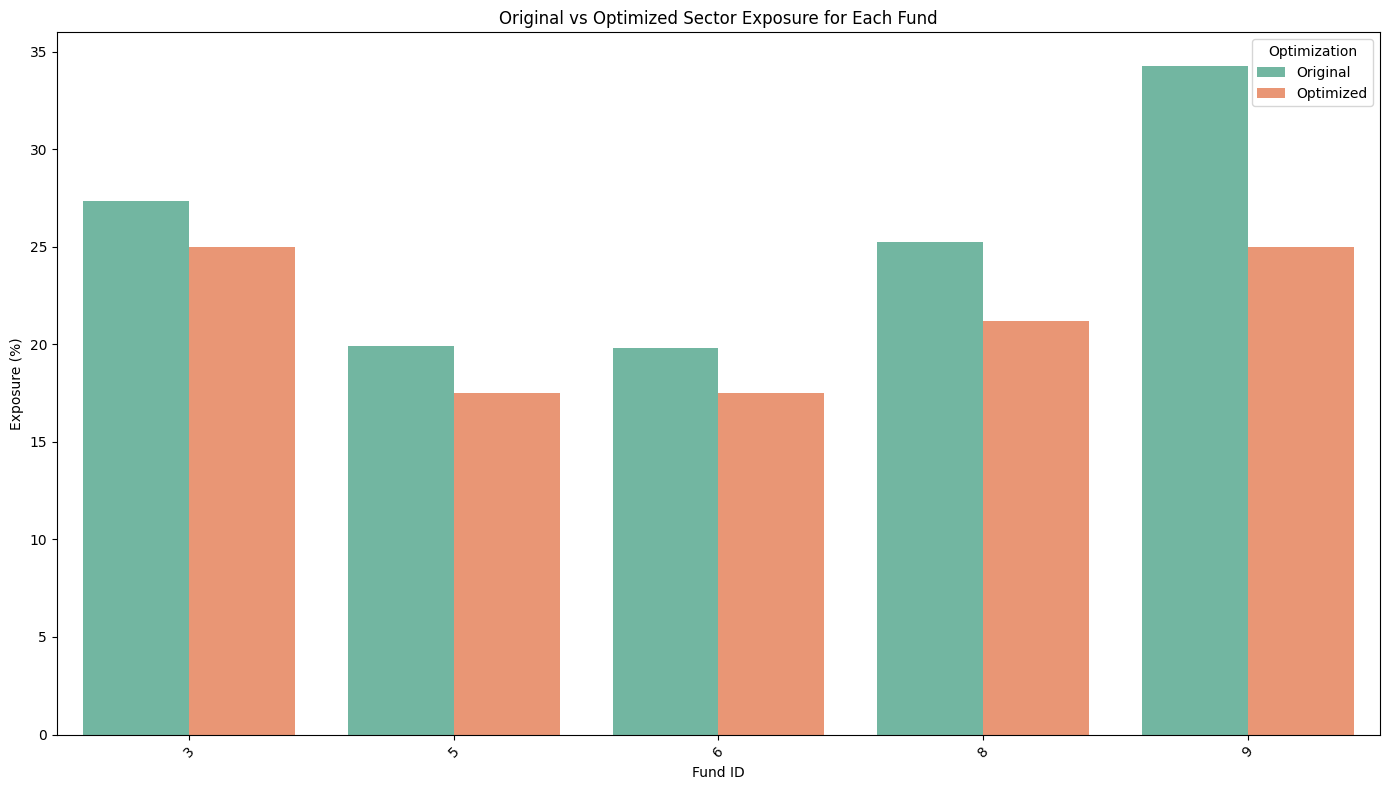

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Original Data
original_data = {
    'Fund_ID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Tech_Exposure_%': [18.65, 21.57, 25.82, 26.27, 26.89, 16.40, 20.23, 49.10, 47.85, 32.10],
    'Healthcare_Exposure_%': [16.37, 44.54, 49.24, 40.05, 20.65, 33.60, 37.80, 19.71, 34.87, 11.30],
    'Finance_Exposure_%': [23.75, 29.63, 17.51, 12.29, 16.51, 22.81, 10.02, 22.37, 45.57, 36.83],
    'Energy_Exposure_%': [10.25, 13.50, 16.82, 18.84, 15.54, 6.44, 6.91, 9.80, 8.79, 15.19]
}

optimized_data = {
    'Fund_ID': [8, 3, 6, 9, 5],
    'Tech_Exposure_%': [35, 20, 10, 40, 20],
    'Healthcare_Exposure_%': [19.71, 60, 40, 25, 30],
    'Finance_Exposure_%': [15, 15, 15, 30, 15],
    'Energy_Exposure_%': [15, 5, 5, 5, 5]
}

# Convert to DataFrames
original_df = pd.DataFrame(original_data)
optimized_df = pd.DataFrame(optimized_data)

# Merge DataFrames for plotting
merged_df = pd.merge(original_df, optimized_df, on='Fund_ID', suffixes=('_Original', '_Optimized'))

# Melt the DataFrame for better plotting with Seaborn
melted_df = pd.melt(merged_df, id_vars=['Fund_ID'], value_vars=['Tech_Exposure_%_Original', 'Healthcare_Exposure_%_Original', 'Finance_Exposure_%_Original', 'Energy_Exposure_%_Original',
                                                                 'Tech_Exposure_%_Optimized', 'Healthcare_Exposure_%_Optimized', 'Finance_Exposure_%_Optimized', 'Energy_Exposure_%_Optimized'],
                     var_name='Type', value_name='Exposure')

# Split 'Type' into 'Sector' and 'Optimization'
melted_df['Sector'] = melted_df['Type'].apply(lambda x: x.split('_')[0])
melted_df['Optimization'] = melted_df['Type'].apply(lambda x: 'Original' if 'Original' in x else 'Optimized')

# Plot
plt.figure(figsize=(14, 8))
sns.barplot(data=melted_df, x='Fund_ID', y='Exposure', hue='Optimization', palette='Set2', ci=None)
plt.title('Original vs Optimized Sector Exposure for Each Fund')
plt.xlabel('Fund ID')
plt.ylabel('Exposure (%)')
plt.legend(title='Optimization')
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.show()